# IMPORT & DATA LOAD

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# install Hangul font

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 5 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,421 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direc

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.rc('font', family='NanumBarunGothic')

In [4]:
df= pd.read_csv("/content/태림_통합데이터3.csv")

In [5]:
df.head()

,ZF_PN,Supplier_PN,Order,ID_Release,Month,Year,Day,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY
0,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240314572,1.656.750
1,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240329575,1.656.750
2,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240405576,1.656.750
3,A0028219,A0028219,PO348384,20240521-004,April,2024,19,4.8,pc,FIRM,SEA,ZFB240419580,1.656.750
4,A0028219,A0028219,PO348384,20240521-004,April,2024,25,8.0,pc,FIRM,SEA,ZFB240412578,1.656.750


# ID_Release

하루 차이 firm + 송장 없음 건수: 104
전체 대비 비율: 0.003329278442922082
        ID_Release Firm/Forecast Shipped_Invoice forecast_date actual_date  \
460   20240527-004          FIRM             NaN    2024-05-27  2024-05-27   
535   20240527-004          FIRM             NaN    2024-05-27  2024-05-27   
593   20240527-004          FIRM             NaN    2024-05-27  2024-05-27   
674   20240527-004          FIRM             NaN    2024-05-27  2024-05-27   
749   20240527-004          FIRM             NaN    2024-05-27  2024-05-28   
908   20240603-004          FIRM             NaN    2024-06-03  2024-06-03   
1039  20240603-004          FIRM             NaN    2024-06-03  2024-06-03   
1188  20240603-004          FIRM             NaN    2024-06-03  2024-06-03   
1349  20240610-004          FIRM             NaN    2024-06-10  2024-06-10   
1480  20240610-004          FIRM             NaN    2024-06-10  2024-06-10   

      lead_time  
460           0  
535           0  
593           0  
674        

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


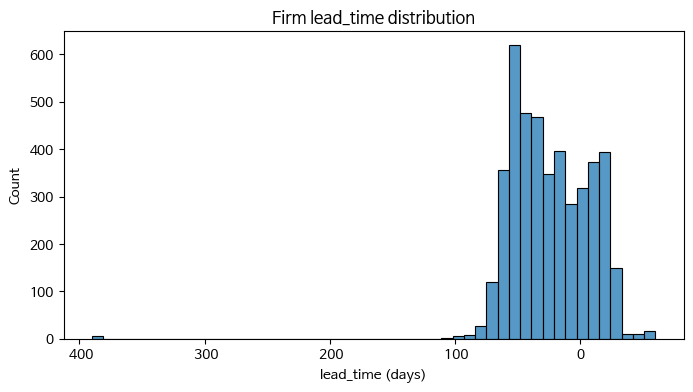

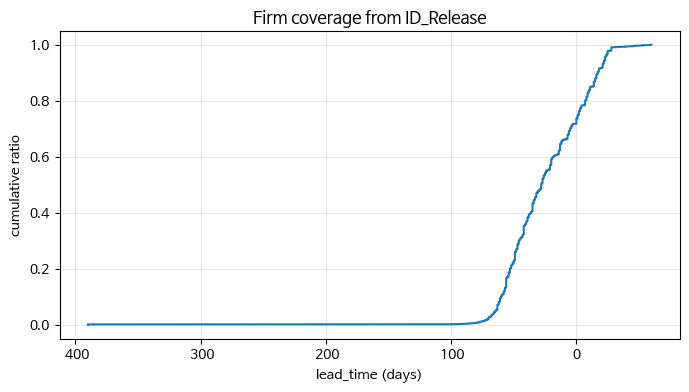

In [17]:

df["forecast_date"] = pd.to_datetime(
    df["ID_Release"].astype(str).str[:8],
    format="%Y%m%d",
    errors="coerce"
)

df["actual_date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-" + df["Day"].astype(str),
    errors="coerce"
)


df["lead_time"] = (df["actual_date"] - df["forecast_date"]).dt.days
df["is_firm"] = df["Firm/Forecast"].astype(str).str.upper().eq("FIRM")
df["has_shipped_invoice"] = df["Shipped_Invoice"].notna() & (
    df["Shipped_Invoice"].astype(str).str.strip() != ""
)


# 6) ID_Release 기준 하루 차이(0~1일)인데 firm이고 송장 없는 건
case_1 = df[
    (df["is_firm"]) &
    (~df["has_shipped_invoice"]) &
    (df["lead_time"].between(0, 1, inclusive="both"))
]

print("하루 차이 firm + 송장 없음 건수:", len(case_1))
print("전체 대비 비율:", len(case_1) / len(df))

# 샘플 확인
print(case_1[[
    "ID_Release", "Firm/Forecast", "Shipped_Invoice",
    "forecast_date", "actual_date", "lead_time"
]].head(10))

# 7) firm이 ID_Release 기준 얼마나 커버하는지
firm_df = df[df["is_firm"] & df["lead_time"].notna()].copy()

print("\nFirm lead_time 요약")
print(firm_df["lead_time"].describe())

print("\n30일 이내 firm 비율:", (firm_df["lead_time"] <= 30).mean())
print("60일 이내 firm 비율:", (firm_df["lead_time"] <= 60).mean())
print("90일 이내 firm 비율:", (firm_df["lead_time"] <= 90).mean())


bins = [-9999, 0, 7, 14, 30, 60, 90, 9999]
labels = ["<=0일", "1주 이내", "2주 이내", "1개월 이내", "2개월 이내", "3개월 이내", "3개월 초과"]

firm_df["lead_bin"] = pd.cut(firm_df["lead_time"], bins=bins, labels=labels)
coverage = firm_df["lead_bin"].value_counts(dropna=False).sort_index()

print("\n구간별 firm 커버리지")
print(coverage)
print("\n구간별 firm 커버리지 비율")
print((coverage / len(firm_df)).round(4))




# 9) 시각화
plt.figure(figsize=(8, 4))
sns.histplot(firm_df["lead_time"], bins=50)
plt.title("Firm lead_time distribution")
plt.xlabel("lead_time (days)")
plt.show()


# 10) 누적 커버리지
sorted_lt = np.sort(firm_df["lead_time"].dropna())
cdf = np.arange(1, len(sorted_lt)+1) / len(sorted_lt)

plt.figure(figsize=(8, 4))
plt.plot(sorted_lt, cdf)
plt.xlabel("lead_time (days)")
plt.ylabel("cumulative ratio")
plt.title("Firm coverage from ID_Release")
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
df

,ZF_PN,Supplier_PN,Order,ID_Release,Month,Year,Day,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY,forecast_date,actual_date,lead_time,is_firm,has_shipped_invoice,after_actual_has_invoice
0,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.400,pc,FIRM,SEA,ZFB240314572,1.656.750,2024-05-21,2024-04-04,-47,True,True,True
1,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.400,pc,FIRM,SEA,ZFB240329575,1.656.750,2024-05-21,2024-04-04,-47,True,True,True
2,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.400,pc,FIRM,SEA,ZFB240405576,1.656.750,2024-05-21,2024-04-04,-47,True,True,True
3,A0028219,A0028219,PO348384,20240521-004,April,2024,19,4.800,pc,FIRM,SEA,ZFB240419580,1.656.750,2024-05-21,2024-04-19,-32,True,True,True
4,A0028219,A0028219,PO348384,20240521-004,April,2024,25,8.000,pc,FIRM,SEA,ZFB240412578,1.656.750,2024-05-21,2024-04-25,-26,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31233,A021N565,A021N565,PO432429,20251110-004,September,2026,28,3.024,PC,FORECAST,SEA,NaN,163.632,2025-11-10,2026-09-28,322,False,False,False
31234,A021N565,A021N565,PO432429,20251110-004,October,2026,19,3.024,PC,FORECAST,SEA,NaN,163.632,2025-11-10,2026-10-19,343,False,False,False
31235,A021N565,A021N565,PO432429,20251110-004,October,2026,26,2.688,PC,FORECAST,SEA,NaN,163.632,2025-11-10,2026-10-26,350,False,False,False
31236,A021N565,A021N565,PO432429,20251110-004,November,2026,2,3.024,PC,FORECAST,SEA,NaN,163.632,2025-11-10,2026-11-02,357,False,False,False


- ID_Release 기준 1일 이내에 firm 상태이면서 송장이 없는 경우가 0.33% 존재하며, 이는 실제 출하와 시스템 입력 간의 시간 차이에 의해 발생하는 것 (그냥 수기 데이터이니깐 있을 법 한 데이터다)
- forecast_date: ID_Relese를 datetime 형태로 교체.
- actual_date: Year, Month, Day를 datetime 형태로 교체
- lead_time: 양수: actual_date > forecast_date → 미래 이벤트
             음수: actual_date < forecast_date → 이미 과거 이벤트(대부분 음수)
- is_firm: Firm -> True, Forecast -> False
- has_shipped_invoice: True -> 출하 완료, False -> 아직 출하 안됨

In [19]:
key = ["ID_Release", "ZF_PN"]

grouped = df.groupby(key)["Firm/Forecast"].agg(lambda x: set(x.str.upper()))

def classify(s):
    if "FORECAST" in s and "FIRM" in s:
        return "전환 가능"
    elif "FIRM" in s:
        return "처음부터 firm"
    elif "FORECAST" in s:
        return "forecast only"
    else:
        return "unknown"

result = grouped.apply(classify)

print(result.value_counts(normalize=True))
print(result.value_counts())

Firm/Forecast
전환 가능            0.987013
forecast only    0.008658
처음부터 firm        0.004329
Name: proportion, dtype: float64
Firm/Forecast
전환 가능            456
forecast only      4
처음부터 firm          2
Name: count, dtype: int64


In [20]:
print("미래 데이터 존재:", (df["lead_time"] > 0).any())
print("과거 데이터 존재:", (df["lead_time"] < 0).any())
print("같은날 데이터 존재:", (df["lead_time"] == 0).any())

print("미래 (lead_time > 0):", (df["lead_time"] > 0).sum())
print("과거 (lead_time < 0):", (df["lead_time"] < 0).sum())
print("당일 (lead_time = 0):", (df["lead_time"] == 0).sum())

미래 데이터 존재: True
과거 데이터 존재: True
같은날 데이터 존재: True
미래 (lead_time > 0): 28003
과거 (lead_time < 0): 3151
당일 (lead_time = 0): 84


- 미래 : ex) ID_Release  = 6/17, actual_date = 6/24
- 과거 : ex) ID_Release  = 6/17, actual_date = 6/10

In [21]:
df["after_actual_has_invoice"] = (
    (df["actual_date"] <= df["forecast_date"]) &
    (df["has_shipped_invoice"])
)

print(df["after_actual_has_invoice"].mean())

0.09651706255201997


In [22]:
# actual_date 기준으로 invoice 있는 비율
df.groupby(pd.cut(df["lead_time"], bins=[-999,0,7,30,999]))["has_shipped_invoice"].mean()

/tmp/ipykernel_48059/1621787290.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["lead_time"], bins=[-999,0,7,30,999]))["has_shipped_invoice"].mean()


,has_shipped_invoice
lead_time,
"(-999, 0]",0.931994
"(0, 7]",0.102990
"(7, 30]",0.016068
"(30, 999]",0.000000


In [23]:
df[df["is_firm"]]["lead_time"].describe()

,lead_time
count,4387.000000
mean,-24.443583
std,32.163289
min,-390.000000
25%,-49.000000
50%,-28.000000
75%,2.000000
max,60.000000


In [24]:
(df["lead_time"] > 0).mean()

np.float64(0.896440233049491)

In [25]:
df["lead_time"].value_counts().head(20)

,count
lead_time,
287,212
294,211
301,208
280,208
308,206
322,202
315,202
329,202
273,200


In [26]:
print("전체:", len(df))
print("미래:", (df["lead_time"] > 0).sum())
print("과거:", (df["lead_time"] < 0).sum())
print("당일:", (df["lead_time"] == 0).sum())

print("\n비율")
print("미래:", (df["lead_time"] > 0).mean())
print("과거:", (df["lead_time"] < 0).mean())
print("당일:", (df["lead_time"] == 0).mean())

전체: 31238
미래: 28003
과거: 3151
당일: 84

비율
미래: 0.896440233049491
과거: 0.10087073436199501
당일: 0.0026890325885139893


- firm 데이터는 과거에 많고, 전체 데이터는 미래가 더 많다. -> 둘다 맞는 말
- forecast-> firm 예측 모델 만들 수 있다고 판단.
- 전체 데이터의 약 89.6%가 ID_Release 기준 미래 출하 일정으로 구성되어 있어,
해당 데이터는 예측 모델 구축에 적합한 구조를 가진다고 판단.
- 반면 약 10%는 과거 이벤트의 사후 기록으로 판단되며,
모델 학습 시 제외하거나 별도 처리할 필요가 있다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


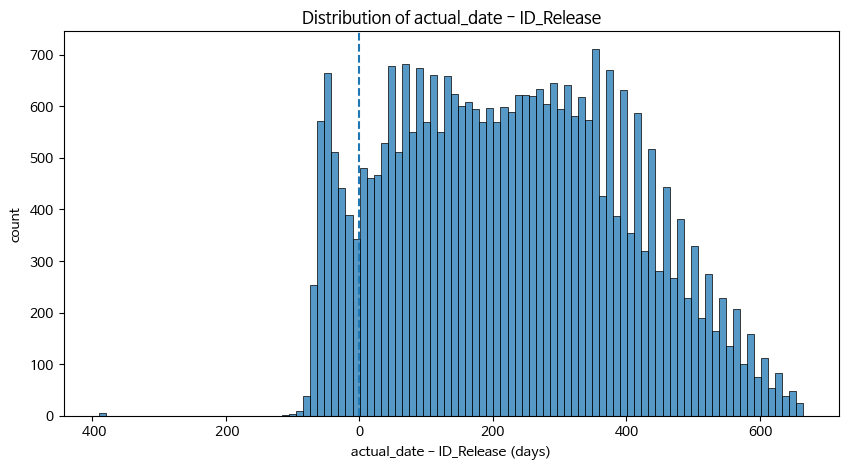

In [27]:
# 1) 날짜 생성
df["forecast_date"] = pd.to_datetime(
    df["ID_Release"].astype(str).str[:8],
    format="%Y%m%d",
    errors="coerce"
)

df["actual_date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-" + df["Day"].astype(str),
    errors="coerce"
)

# 2) 차이 계산
df["date_diff"] = (df["actual_date"] - df["forecast_date"]).dt.days

# 3) 히스토그램
plt.figure(figsize=(10, 5))
sns.histplot(df["date_diff"].dropna(), bins=100)
plt.axvline(0, linestyle="--")
plt.xlabel("actual_date - ID_Release (days)")
plt.ylabel("count")
plt.title("Distribution of actual_date - ID_Release")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


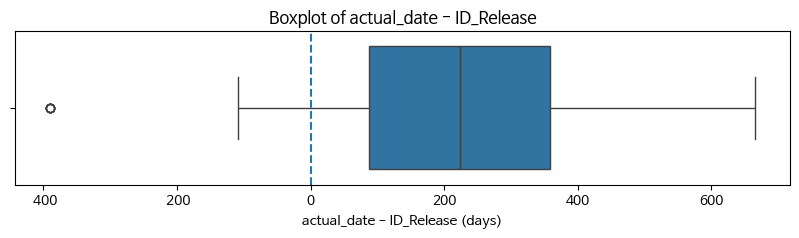

In [28]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df["date_diff"].dropna())
plt.axvline(0, linestyle="--")
plt.xlabel("actual_date - ID_Release (days)")
plt.title("Boxplot of actual_date - ID_Release")
plt.show()

In [29]:
print(df["date_diff"].describe())
print("음수 비율:", (df["date_diff"] < 0).mean())
print("0 비율:", (df["date_diff"] == 0).mean())
print("양수 비율:", (df["date_diff"] > 0).mean())

count    31238.000000
mean       228.922914
std        172.686338
min       -390.000000
25%         88.000000
50%        224.000000
75%        359.000000
max        665.000000
Name: date_diff, dtype: float64
음수 비율: 0.10087073436199501
0 비율: 0.0026890325885139893
양수 비율: 0.896440233049491


   horizon_days  count  firm_ratio
0             7    385    0.953247
1            14    706    0.936261
2            28   1321    0.907646
3            56   2802    0.440043


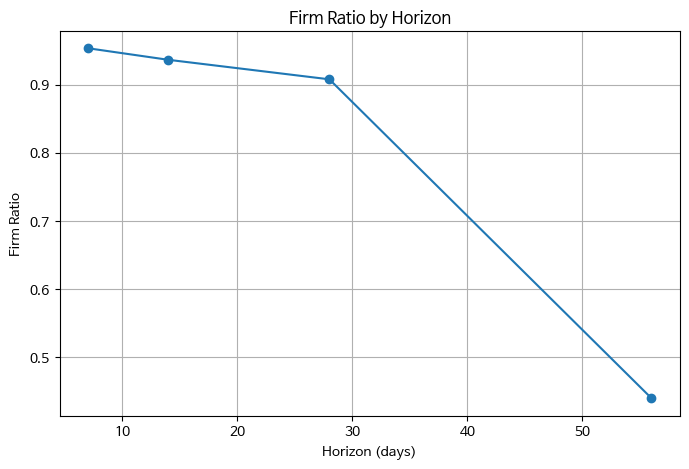

In [30]:
df_pos = df[df["lead_time"] >= 0].copy()
result = []

for h in [7, 14, 28, 56]:
    subset = df_pos[df_pos["lead_time"] <= h]

    result.append({
        "horizon_days": h,
        "count": len(subset),
        "firm_ratio": subset["is_firm"].mean()
    })

result_df = pd.DataFrame(result)
print(result_df)

plt.figure(figsize=(8,5))
plt.plot(result_df["horizon_days"], result_df["firm_ratio"], marker="o")
plt.xlabel("Horizon (days)")
plt.ylabel("Firm Ratio")
plt.title("Firm Ratio by Horizon")
plt.grid()
plt.show()

# Forecast 구간

In [31]:
df = df.sort_values(["ID_Release", "ZF_PN", "actual_date"])

In [39]:
df["status"] = df["Firm/Forecast"].astype(str).str.upper().str.strip()

In [40]:
print(df["status"].value_counts())
print(df["status"].unique())

['FIRM' 'FORECAST']


In [42]:
boundary_rows = []

for (rid, zf), g in df.groupby(["ID_Release", "ZF_PN"]):
    g = g.sort_values("actual_date").reset_index(drop=True)

    firm_dates = g.loc[g["status"] == "FIRM", "actual_date"]
    fcst_dates = g.loc[g["status"] == "FORECAST", "actual_date"]

    if len(firm_dates) > 0 and len(fcst_dates) > 0:
        last_firm = firm_dates.max()
        first_fcst = fcst_dates.min()

        boundary_rows.append({
            "ID_Release": rid,
            "ZF_PN": zf,
            "last_firm_date": last_firm,
            "first_forecast_date": first_fcst,
            "gap_days": (first_fcst - last_firm).days
        })

boundary_df = pd.DataFrame(boundary_rows)

print(boundary_df["gap_days"].describe())
print(boundary_df.head())

count    456.000000
mean      19.028509
std       21.448155
min        6.000000
25%        7.000000
50%       10.000000
75%       24.250000
max      202.000000
Name: gap_days, dtype: float64
     ID_Release      ZF_PN last_firm_date first_forecast_date  gap_days
0  20240521-004   A0028219     2024-06-10          2024-06-26        16
1  20240521-004  A0030814X     2024-05-27          2024-07-05        39
2  20240521-004   A0049000     2024-06-10          2024-06-25        15
3  20240521-004   A0067885     2024-06-06          2024-06-20        14
4  20240521-004   A0070270     2024-06-18          2024-06-25         7


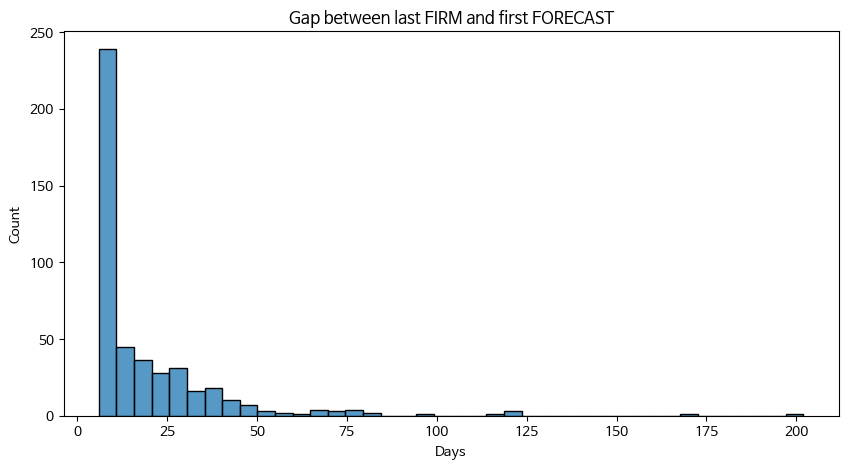

In [43]:
plt.figure(figsize=(10,5))
sns.histplot(boundary_df["gap_days"], bins=40)
plt.title("Gap between last FIRM and first FORECAST")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

In [44]:
print((boundary_df["gap_days"] < 0).sum())
boundary_df["gap_days"].describe()
sample = boundary_df.sort_values("gap_days").iloc[:5]

for _, row in sample.iterrows():
    rid = row["ID_Release"]
    zf = row["ZF_PN"]

    print("\n====================")
    print(rid, zf)

    g = df[(df["ID_Release"] == rid) & (df["ZF_PN"] == zf)]
    print(g.sort_values("actual_date")[["actual_date", "status"]])

0

20251013-004 A0030814X
      actual_date    status
29743  2025-08-12      FIRM
29744  2025-08-18      FIRM
29745  2025-08-31      FIRM
29746  2025-09-16      FIRM
29747  2025-09-19      FIRM
29748  2025-09-23      FIRM
29749  2025-10-15      FIRM
29750  2025-10-29      FIRM
29751  2025-11-05      FIRM
29752  2025-11-11  FORECAST
29753  2025-11-18  FORECAST
29754  2025-11-25  FORECAST
29755  2025-12-02  FORECAST
29756  2025-12-10  FORECAST

20240628-003 A0030814X
     actual_date    status
2726  2024-05-10      FIRM
2727  2024-05-23      FIRM
2728  2024-05-31      FIRM
2729  2024-07-05      FIRM
2730  2024-07-08      FIRM
2731  2024-07-15      FIRM
2732  2024-07-24      FIRM
2733  2024-07-30  FORECAST
2734  2024-08-07  FORECAST
2735  2024-08-14  FORECAST
2736  2024-08-21  FORECAST
2737  2024-08-29  FORECAST
2738  2024-09-10  FORECAST
2739  2024-09-17  FORECAST
2740  2024-09-24  FORECAST
2741  2024-10-02  FORECAST
2742  2024-10-09  FORECAST
2743  2024-10-21  FORECAST
2744  2024-10-29 

- 이 주문이 firm 구간(4주)에 들어갈지 예측 이것도 괜찮은 예측이지 않을까 싶다.